In [1]:
from modules.preprocessing import create_features, get_data, get_preprocessor, split_data
import pandas as pd
import numpy as np

features, target = get_data()
preprocessor = get_preprocessor(features, target)
features = create_features(features)

X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(features, target)
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)

In [2]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    random_state=42,
    force_col_wise=True,
    max_depth=12,
    num_leaves=51,
    n_estimators=170,
    learning_rate=0.01,
    # is_unbalance=True,
    # class_weight='balanced',
    scale_pos_weight=5,
)

lgbm_model.fit(X_train, y_train)
lgbm_valid_pred = lgbm_model.predict(X_valid)
lgbm_valid_pred_proba = lgbm_model.predict_proba(X_valid)[:, 1]

[LightGBM] [Info] Number of positive: 1154, number of negative: 4471
[LightGBM] [Info] Total Bins 1377
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205156 -> initscore=-1.354378
[LightGBM] [Info] Start training from score -1.354378


/home/tera/workspace/SKN21-2nd-1Team/ne_eun/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tera/workspace/SKN21-2nd-1Team/ne_eun/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [3]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=830,
    max_depth=3,
    learning_rate=0.01,
    scale_pos_weight=4.5,
    random_state=42,
    objective='binary:logistic',
    tree_method='approx',
    max_delta_step=3,
)

xgb_model.fit(X_train, y_train)
xgb_valid_pred = xgb_model.predict(X_valid)
xgb_valid_pred_proba = xgb_model.predict_proba(X_valid)[:, 1]

In [4]:
ensemble_valid_pred_proba = (lgbm_valid_pred_proba + xgb_valid_pred_proba) / 2
ensemble_valid_pred = (ensemble_valid_pred_proba >= 0.48).astype(int)

In [5]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(y_valid, ensemble_valid_pred)
f1 = f1_score(y_valid, ensemble_valid_pred)
recall = recall_score(y_valid, ensemble_valid_pred)
precision = precision_score(y_valid, ensemble_valid_pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

Validation 성능 - Accuracy: 0.7851, F1 Score: 0.6030, Recall: 0.7927, Precision: 0.4865


In [6]:
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
lgbm_test_pred = lgbm_model.predict(X_test)
lgbm_test_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]

/home/tera/workspace/SKN21-2nd-1Team/ne_eun/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tera/workspace/SKN21-2nd-1Team/ne_eun/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
ensemble_test_pred_proba = (xgb_test_pred_proba + lgbm_test_pred_proba) / 2
ensemble_test_pred = (ensemble_test_pred_proba >= 0.48).astype(int)

In [8]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(y_test, ensemble_test_pred)
f1 = f1_score(y_test, ensemble_test_pred)
recall = recall_score(y_test, ensemble_test_pred)
precision = precision_score(y_test, ensemble_test_pred)

print(f"test 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

test 성능 - Accuracy: 0.7840, F1 Score: 0.5903, Recall: 0.7827, Precision: 0.4738


/home/tera/workspace/SKN21-2nd-1Team/ne_eun/.venv/lib/python3.10/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


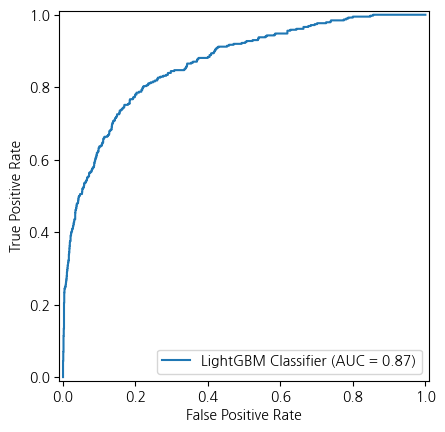

In [9]:

from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

rfc_roc = roc_auc_score(y_valid, ensemble_valid_pred_proba)
fpr, recall, thresh = roc_curve(y_valid, ensemble_valid_pred_proba)
disp_roc_rfc = RocCurveDisplay(
    fpr=fpr, tpr=recall,
    roc_auc=rfc_roc,
    estimator_name='LightGBM Classifier'
)
disp_roc_rfc.plot()
